In [1]:
from scipy.io import mmread
from scipy.sparse import save_npz
import numpy as np

sample = 1
path = 'data/sample'+str(sample)+'/matrix.mtx'
sparse_matrix = mmread(path)
X = sparse_matrix.toarray()
X = X.transpose()
X

array([[  0,   0,   0, ...,   1, 138,   0],
       [  0,   0,   0, ...,   2,  52,   3],
       [  0,   0,   0, ...,   9, 274,   3],
       ...,
       [  0,   0,   0, ...,   6, 201,   0],
       [  0,   0,   0, ...,   8, 118,   2],
       [  0,   0,   0, ...,   2, 126,   3]])

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE  # For 2D visualization
from keras.layers import Input, Dense, Layer
from keras.models import Model
from keras import backend as K

# Preprocessing
X = np.log1p(X)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

input_dim = X_scaled.shape[1]
encoding_dim = 32  # Latent space dimension
hidden_dim = 64 

# Step 1: Pretrain Autoencoder
input_layer = Input(shape=(input_dim,))

# Two-layer encoder
encoder = Dense(hidden_dim, activation='relu')(input_layer)
encoder = Dense(encoding_dim, activation='relu')(encoder)

# Decoder
decoder = Dense(hidden_dim, activation='relu')(encoder)
output_layer = Dense(input_dim, activation='sigmoid')(decoder)

autoencoder = Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(X_scaled, X_scaled, epochs=20, batch_size=32, shuffle=True)

# Extract encoded features
encoder_model = Model(inputs=input_layer, outputs=encoder)

2025-10-10 21:25:37.306874: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-10 21:25:37.341827: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-10 21:25:37.901433: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2025-10-10 21:25:40.119242: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-10-10 21:25:40.190

Epoch 1/20
130/130 [==============================] - 3s 19ms/step - loss: 0.0284
Epoch 2/20
130/130 [==============================] - 2s 19ms/step - loss: 0.0051
Epoch 3/20
130/130 [==============================] - 3s 20ms/step - loss: 0.0050
Epoch 4/20
130/130 [==============================] - 3s 20ms/step - loss: 0.0050
Epoch 5/20
130/130 [==============================] - 3s 19ms/step - loss: 0.0049
Epoch 6/20
130/130 [==============================] - 3s 19ms/step - loss: 0.0047
Epoch 7/20
130/130 [==============================] - 3s 20ms/step - loss: 0.0045
Epoch 8/20
130/130 [==============================] - 3s 20ms/step - loss: 0.0044
Epoch 9/20
130/130 [==============================] - 3s 20ms/step - loss: 0.0044
Epoch 10/20
130/130 [==============================] - 3s 20ms/step - loss: 0.0043
Epoch 11/20
130/130 [==============================] - 3s 20ms/step - loss: 0.0042
Epoch 12/20
130/130 [==============================] - 3s 20ms/step - loss: 0.0041
Epoch 13/20
1

In [6]:
n_clusters = 4     # Adjust based on your data
encoded_data = encoder_model.predict(X_scaled)

# Step 2: Initialize Clusters
kmeans = KMeans(n_clusters=n_clusters, n_init=10)
kmeans.fit(encoded_data)
#cluster_centers = kmeans.cluster_centers_

# Get final cluster labels
cluster_labels = kmeans.predict(encoded_data)

130/130 [==============================] - 0s 2ms/step


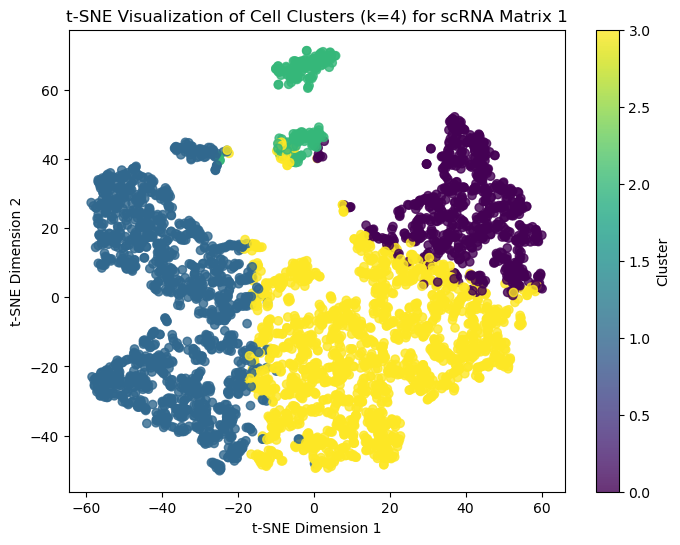

In [7]:
import os
prefix_path = 'compressed/neural/sample'+str(sample)+'/k'+str(n_clusters)
if not os.path.isdir(prefix_path):
    os.mkdir(prefix_path)

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(encoded_data)  # Use encoded features

plt.figure(figsize=(8, 6))
plt.scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=cluster_labels, cmap='viridis', alpha=0.8
)
plt.title('t-SNE Visualization of Cell Clusters (k='+str(n_clusters)+') for scRNA Matrix '+str(sample))
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.colorbar(label='Cluster')
plt.savefig(prefix_path+'/clusters.png')
plt.show()

In [8]:
import pickle

# Pickle the array and save to a file
filename = prefix_path + '/cluster_labels.pkl'
with open(filename, 'wb') as file:
    pickle.dump(cluster_labels, file)